## 1. Introduction

So far, we have worked with a dataset containing only one feature: study hours. Each of the 20 training examples maps the number of study hours to an exam score. We then applied Gradient Descent to find the parameters $w$ and $b$ that minimize the cost function and obtain a linear regression model that makes good predictions.

> **Recap**
>
> Before we progess further, let's briefly recall the two core equations from the previous notebook.
>
> The prediction model was
>
> $$
> f(x)=wx+b
> $$
>
> and the corresponding cost function was
>
> $$
> J(w,b)
> =
> \frac{1}{2m}
> \sum_{i=1}^{m}
> \left(f(x^{(i)})-y^{(i)}\right)^2.
> $$

In practice, study hours are likely to be a good predictor of exam performance, but they are probably not the only factor influencing the result. Other features may also contain useful information and help improve our predictions. To address this, we will **extend our previous Gradient Descent implementation** so that it can optimize a linear regression model with multiple input features. Although the implementation changes, the underlying idea of Gradient Descent remains the same.

In addition, we will introduce two important concepts when working with data: **feature scaling** and **feature engineering**. Feature scaling can significantly improve the convergence speed of Gradient Descent, while feature engineering enables the model to represent more complex relationships between the input features and the target variable.

> **Note**
>
> Throughout this notebook, we will refer to the implementation of Gradient Descent. The complete implementations of both **univariate** and **multiple linear regression** can be found in the `src/ml_from_scratch` directory.
>
> If you are interested in the behavior of the individual functions, you may also want to explore the unit tests in the `tests` directory. Besides verifying correctness, they provide additional examples of how the implementation is intended to be used.

Before moving on to the next chapter, please execute the code cell below to import the required dependencies and generate the example dataset.

In [1]:
import matplotlib.pyplot as plt

from utils.helpers import (
    generate_multiple_linear_regression_dataset,
    create_dataset_table
)

from utils.plotting import (
    plot_features_vs_target
)

X, y = generate_multiple_linear_regression_dataset()

## 2. The Dataset

As mentioned in the introduction, we will now work with a dataset containing multiple features. Once again, we will use a synthetic dataset. Besides **study hours**, we will additionally consider **lecture attendance**, the **number of completed practice tests**, and the **hours of sleep before the exam**. Each feature represents a factor that could plausibly influence a student's exam performance.

Our dataset consists of **20 training examples** and **four input features**. Together with the corresponding exam scores, the complete dataset contains **20 rows and five columns**.

An important assumption of linear regression is that the relationship between each input feature and the target value is approximately linear. Therefore, we will initially assume that all four features have a linear relationship with the exam score.

Later in this notebook, we will revisit the **sleep** feature and replace its linear relationship with a nonlinear one. This will motivate the use of **feature engineering** and **polynomial regression**, allowing us to model more complex relationships while still using linear regression.

In the next code cell, you can inspect the complete dataset.

In [2]:
table = create_dataset_table(X, y)
table

Training Example,Study Hours,Attendance (%),Practice Tests,Sleep (h),Exam Score
1,1,56.5,0,5.6,39.4
2,18,96.2,8,8.1,118.8
3,16,88.8,7,8.1,111.7
4,2,57.0,0,5.7,42.5
5,9,72.5,3,6.8,77.0
6,6,66.1,2,6.1,64.6
7,12,79.7,6,7.2,95.5
8,4,66.7,1,5.9,50.7
9,19,94.9,8,8.4,124.0
10,17,89.9,8,7.9,114.7


After inspecting the dataset, we can now introduce an important notation that will be used throughout the rest of this notebook.

In the previous notebook, we worked with only a single input feature. Therefore, we represented our training data by the feature vector

$$
x \in \mathbb{R}^{20},
$$

where each element corresponded to the number of study hours of one training example.

Since our new dataset contains **multiple input features**, we now organize the input data in the **feature matrix**

$$
X \in \mathbb{R}^{20 \times 4},
$$

where each **row** represents one training example and each **column** represents one feature.

The corresponding exam scores are stored separately in the target vector

$$
y \in \mathbb{R}^{20}.
$$

To refer to an individual value in the feature matrix, we use the notation

$$
x_j^{(i)},
$$

where the superscript \(i\) denotes the **training example** and the subscript \(j\) denotes the **feature**.

For example, $x_2^{(5)}$ refers to the value of the **second feature** (lecture attendance) of the **fifth training example**. You can verify this directly in the dataset shown above. The correct value is 72.5 % Attendance.

> **Note**
>
> In mathematical notation, indices usually start at **1**. Therefore, the feature index is written as j = 1 ... n and the training example index as i = 1 ... m.
>
> In Python and NumPy, however, arrays use **zero-based indexing**. Throughout this notebook, we use mathematical indexing when discussing the theory and Python indexing when working with code.

Although the dataset table provides a good overview of the individual training examples, it can be difficult to recognize relationships between the input features and the target variable by simply looking at the numbers.

A visual representation often reveals patterns that are much harder to identify in tabular form. Therefore, the following plots show each feature against the exam score. Since the data was generated using a linear model, we expect to observe approximately linear relationships between every feature and the target variable.

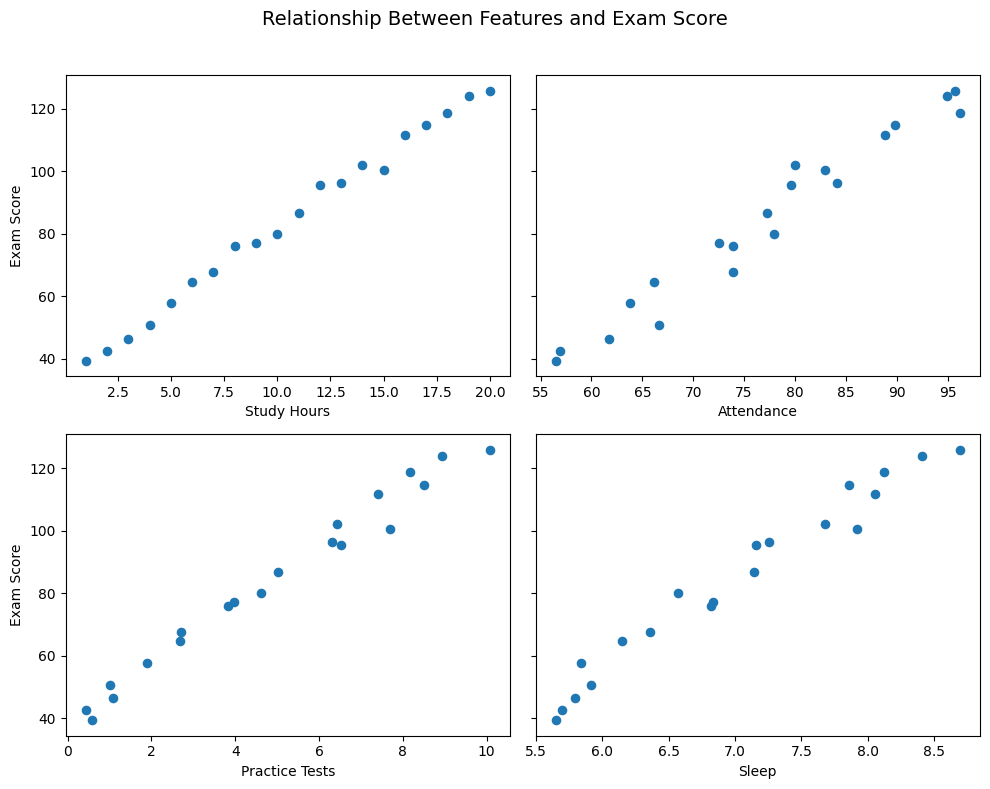

In [3]:
feature_names = ["Study Hours", "Attendance", "Practice Tests", "Sleep"]
plot_features_vs_target(X, y, feature_names)
plt.show()

Each feature exhibits an approximately linear relationship with the exam score. However, none of the features alone explains the target perfectly. This motivates combining all available features into a single prediction model, which is exactly what multiple linear regression does.

## 3. Multiple Linear Regression

Compared to univariate linear regression, the main difference is that our model now uses **multiple input features** instead of just one. Consequently, we no longer optimize a single weight parameter $w$, but a **weight vector**

$$
\mathbf{w} =
\begin{bmatrix}
w_1 \\
w_2 \\
\vdots \\
w_n
\end{bmatrix},
$$

where each weight corresponds to one input feature. In addition to the weight vector, the model still contains the bias parameter $b$.

The prediction model therefore becomes

$$
\hat{y}
=
w_1x_1+w_2x_2+\cdots+w_nx_n+b.
$$

Although the equation looks more complicated than in the univariate case, the underlying idea remains exactly the same. Each feature contributes to the prediction according to its corresponding weight, and the bias parameter shifts the prediction independently of the input features.

Instead of writing the weighted sum explicitly, we can express the same computation more compactly using vector notation:

$$
\hat{y}
=
\mathbf{w}^T\mathbf{x}+b.
$$

Here, $\mathbf{x}$ denotes the feature vector of a **single training example**, while $\mathbf{w}$ contains the corresponding weight parameters. The dot product computes the weighted sum of all input features and therefore produces a single prediction $\hat{y}$.

This compact notation will become particularly useful in the next chapter, where we extend gradient descent to optimize all weight parameters simultaneously.

## 4. Gradient Descent for Multiple Features

In the previous section, we derived the prediction model for a single training example. During training, however, Gradient Descent evaluates the cost function over the **entire dataset**. Instead of processing one training example at a time, we can stack all feature vectors into the feature matrix $\mathbf{X}$ and compute all predictions simultaneously.

> **Recap**
>
> Gradient Descent still follows exactly the same optimization principle as in the univariate case. The algorithm repeatedly updates the model parameters in the direction that decreases the cost function most rapidly. In the previous notebook, we visualized this process using the cost curve and the cost surface. With multiple weight parameters, such visualizations are no longer practical because the optimization takes place in a higher-dimensional parameter space.

**Prediction for the Entire Dataset**

The prediction model therefore becomes

$$
\hat{\mathbf{y}}
=
\mathbf{X}\mathbf{w}+b,
$$

where each element of $\hat{\mathbf{y}}$ corresponds to the predicted exam score of one training example.

Compared to the implementation of univariate linear regression, the prediction function has hardly changed.

```python
# Univariate Linear Regression
y_hat = x * w + b

# Multiple Linear Regression
y_hat = X @ w + b
```

We simply replace the feature vector by the feature matrix and the scalar weight by the weight vector.

**Cost Function**

As before, Gradient Descent minimizes the cost function. The only difference is that our prediction model now depends on multiple weight parameters instead of just one.

The cost function therefore becomes

$$
J(w_1,\ldots,w_n,b)
=
\frac{1}{2m}
\sum_{i=1}^{m}
\left(\hat{y}^{(i)}-y^{(i)}\right)^2.
$$

Although the notation has changed, the objective remains exactly the same: we want to find the model parameters that minimize the prediction error over the entire training dataset.

**Update Rules**

Since the model now contains multiple weight parameters, we also have to compute one partial derivative for every weight parameter.

The update rule for the individual weights therefore becomes

$$
w_j
:=
w_j
-
\alpha
\frac{\partial}{\partial w_j}
J(w_1,\ldots,w_n,b),
\qquad
j=1,\ldots,n.
$$

The bias parameter is updated analogously:

$$
b
:=
b
-
\alpha
\frac{\partial}{\partial b}
J(w_1,\ldots,w_n,b).
$$

Each partial derivative measures how the cost changes with respect to one model parameter while keeping all remaining parameters fixed.

**Vectorized Implementation**

Fortunately, we do not have to compute every partial derivative individually. By exploiting matrix multiplication, all weight gradients can be computed simultaneously as

$$
\nabla_{\mathbf{w}}J
=
\frac{1}{m}
\mathbf{X}^{T}
(\hat{\mathbf{y}}-\mathbf{y}),
$$

while the derivative with respect to the bias becomes

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(\hat{y}^{(i)}-y^{(i)}\right).
$$

These equations correspond directly to our implementation:

```python
error = predict(X, w, b) - y

dj_dw = X.T @ error / m
dj_db = np.sum(error) / m
```

Instead of iterating over every training example and every feature using nested loops, NumPy performs these operations internally. This technique is called **vectorization**. Besides making the implementation shorter and easier to read, vectorized code is significantly faster because it relies on highly optimized numerical libraries.

> **Note**
>
> Vectorization is one of the most important concepts in scientific computing with NumPy. Many machine learning libraries, including scikit-learn, TensorFlow, and PyTorch, rely heavily on vectorized operations instead of explicit Python loops.

Although our implementation is now complete, one important question remains: **How do we choose the hyperparameters?**

In particular, the learning rate $\alpha$ has a significant influence on the behavior of Gradient Descent. If it is chosen too small, the algorithm converges slowly. If it is chosen too large, the algorithm may fail to converge altogether.

In the next chapter, we will experiment with different learning rates and numbers of iterations. By visualizing the **cost history**, we will develop an intuition for how these hyperparameters affect the convergence of Gradient Descent.

## 5. Hyperparameters and Convergence

## 6. Feature Scaling

## 7. Feature Engineering

## 8. Polynomial Regression